# Automotive Component Detection — Training Pipeline
**Dissertation:** Deep Learning-Based Detection and Localization of Automotive Components

**Instructions:**
1. Go to **Runtime → Change runtime type → T4 GPU**
2. Run all cells in order
3. Results are saved to Google Drive automatically

## 1. Setup — GPU check & installations

In [2]:
import torch

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    # Corrected attribute from total_mem to total_memory
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected! Go to Runtime > Change runtime type > T4 GPU")


PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


In [3]:
# Install required packages
!pip install ultralytics roboflow -q
print("Packages installed successfully!")

Packages installed successfully!


In [4]:
# Mount Google Drive to save results
from google.colab import drive
drive.mount('/content/drive')

# Create project folder in Drive
import os
DRIVE_PROJECT = '/content/drive/MyDrive/dissertation_results'
os.makedirs(DRIVE_PROJECT, exist_ok=True)
print(f"Results will be saved to: {DRIVE_PROJECT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results will be saved to: /content/drive/MyDrive/dissertation_results


## 2. Download dataset from Roboflow

In [5]:
from roboflow import Roboflow

# Enter your Roboflow API key here
ROBOFLOW_API_KEY = "HflL48lLaUJcggGlWRtj"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("team-data").project("car-parts-ybiev")
version = project.version(1)  # Update version number if needed
dataset = version.download("yolov8", location="/content/dataset")

print(f"\nDataset downloaded to: /content/dataset")

loading Roboflow workspace...
loading Roboflow project...

Dataset downloaded to: /content/dataset


## 3. Explore the dataset

In [6]:
import yaml
import glob
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Load dataset config
with open('/content/dataset/data.yaml', 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config['names']
num_classes = data_config['nc']
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

# Count images per split
for split in ['train', 'valid', 'test']:
    imgs = glob.glob(f'/content/dataset/{split}/images/*')
    labels = glob.glob(f'/content/dataset/{split}/labels/*')
    print(f"\n{split}: {len(imgs)} images, {len(labels)} label files")

Number of classes: 50
Classes: ['AIR COMPRESSOR', 'ALTERNATOR', 'BATTERY', 'BRAKE CALIPER', 'BRAKE PAD', 'BRAKE ROTOR', 'CAMSHAFT', 'CARBERATOR', 'CLUTCH PLATE', 'COIL SPRING', 'CRANKSHAFT', 'CYLINDER HEAD', 'DISTRIBUTOR', 'ENGINE BLOCK', 'ENGINE VALVE', 'FUEL INJECTOR', 'FUSE BOX', 'GAS CAP', 'HEADLIGHTS', 'IDLER ARM', 'IGNITION COIL', 'INSTRUMENT CLUSTER', 'LEAF SPRING', 'LOWER CONTROL ARM', 'MUFFLER', 'OIL FILTER', 'OIL PAN', 'OIL PRESSURE SENSOR', 'OVERFLOW TANK', 'OXYGEN SENSOR', 'PISTON', 'PRESSURE PLATE', 'RADIATOR', 'RADIATOR FAN', 'RADIATOR HOSE', 'RADIO', 'RIM', 'SHIFT KNOB', 'SIDE MIRROR', 'SPARK PLUG', 'SPOILER', 'STARTER', 'TAILLIGHTS', 'THERMOSTAT', 'TORQUE CONVERTER', 'TRANSMISSION', 'VACUUM BRAKE BOOSTER', 'VALVE LIFTER', 'WATER PUMP', 'WINDOW REGULATOR']

train: 6118 images, 6118 label files

valid: 3146 images, 3146 label files

test: 2534 images, 2534 label files


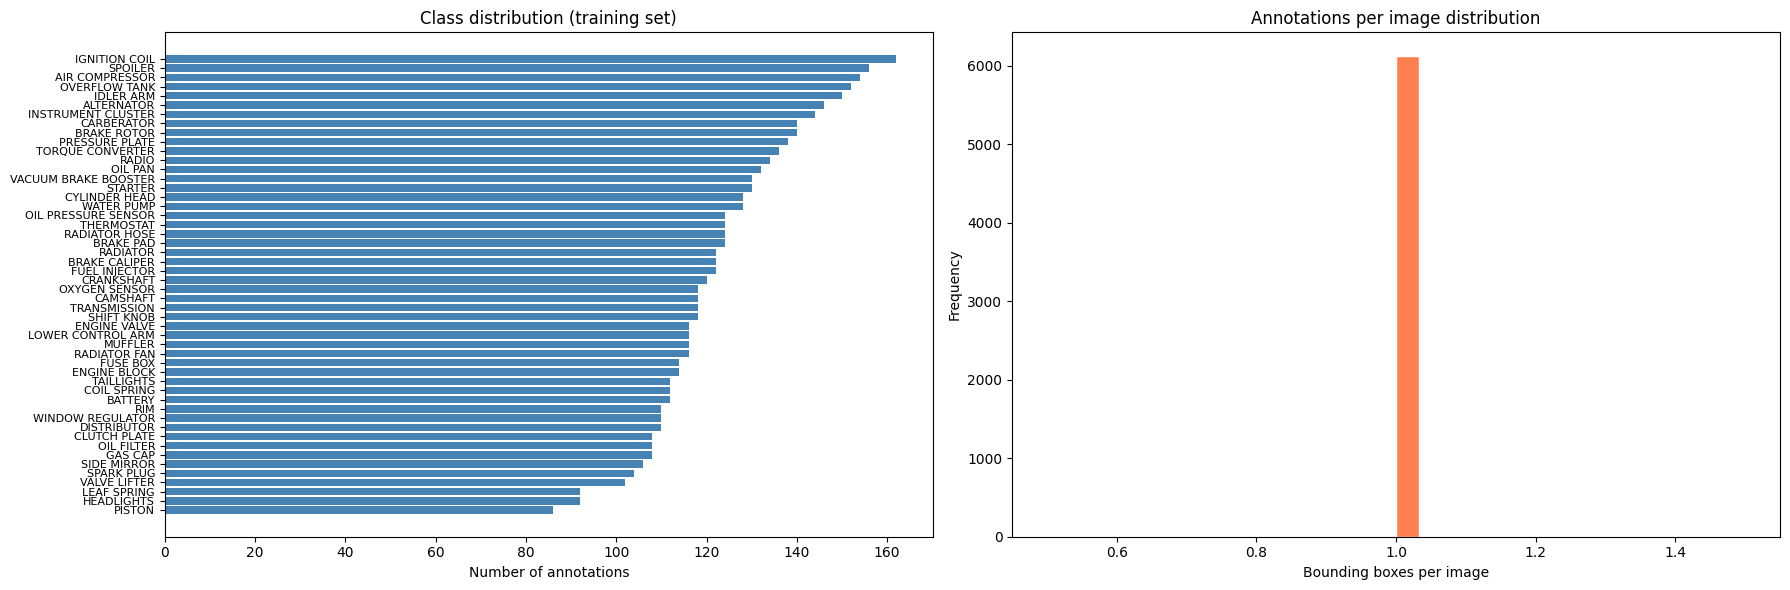


Total annotations: 6118
Avg bounding boxes per image: 1.0

Top 10 classes:
  IGNITION COIL: 162
  SPOILER: 156
  AIR COMPRESSOR: 154
  OVERFLOW TANK: 152
  IDLER ARM: 150
  ALTERNATOR: 146
  INSTRUMENT CLUSTER: 144
  CARBERATOR: 140
  BRAKE ROTOR: 140
  PRESSURE PLATE: 138

Bottom 5 classes (potential problems):
  SPARK PLUG: 104
  VALVE LIFTER: 102
  LEAF SPRING: 92
  HEADLIGHTS: 92
  PISTON: 86


In [7]:
# Analyze class distribution across training set
class_counts = Counter()
bbox_counts = []

train_labels = glob.glob('/content/dataset/train/labels/*.txt')
for label_file in train_labels:
    with open(label_file, 'r') as f:
        lines = f.readlines()
        bbox_counts.append(len(lines))
        for line in lines:
            cls_id = int(line.strip().split()[0])
            class_counts[cls_id] += 1

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Class distribution
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
names = [class_names[c] if c < len(class_names) else f'class_{c}' for c, _ in sorted_classes]
counts = [cnt for _, cnt in sorted_classes]

axes[0].barh(range(len(names)), counts, color='steelblue')
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=8)
axes[0].set_xlabel('Number of annotations')
axes[0].set_title('Class distribution (training set)')
axes[0].invert_yaxis()

# Bounding boxes per image
axes[1].hist(bbox_counts, bins=30, color='coral', edgecolor='white')
axes[1].set_xlabel('Bounding boxes per image')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Annotations per image distribution')

plt.tight_layout()
plt.savefig(f'{DRIVE_PROJECT}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal annotations: {sum(counts)}")
print(f"Avg bounding boxes per image: {np.mean(bbox_counts):.1f}")
print(f"\nTop 10 classes:")
for name, count in zip(names[:10], counts[:10]):
    print(f"  {name}: {count}")
print(f"\nBottom 5 classes (potential problems):")
for name, count in zip(names[-5:], counts[-5:]):
    print(f"  {name}: {count}")

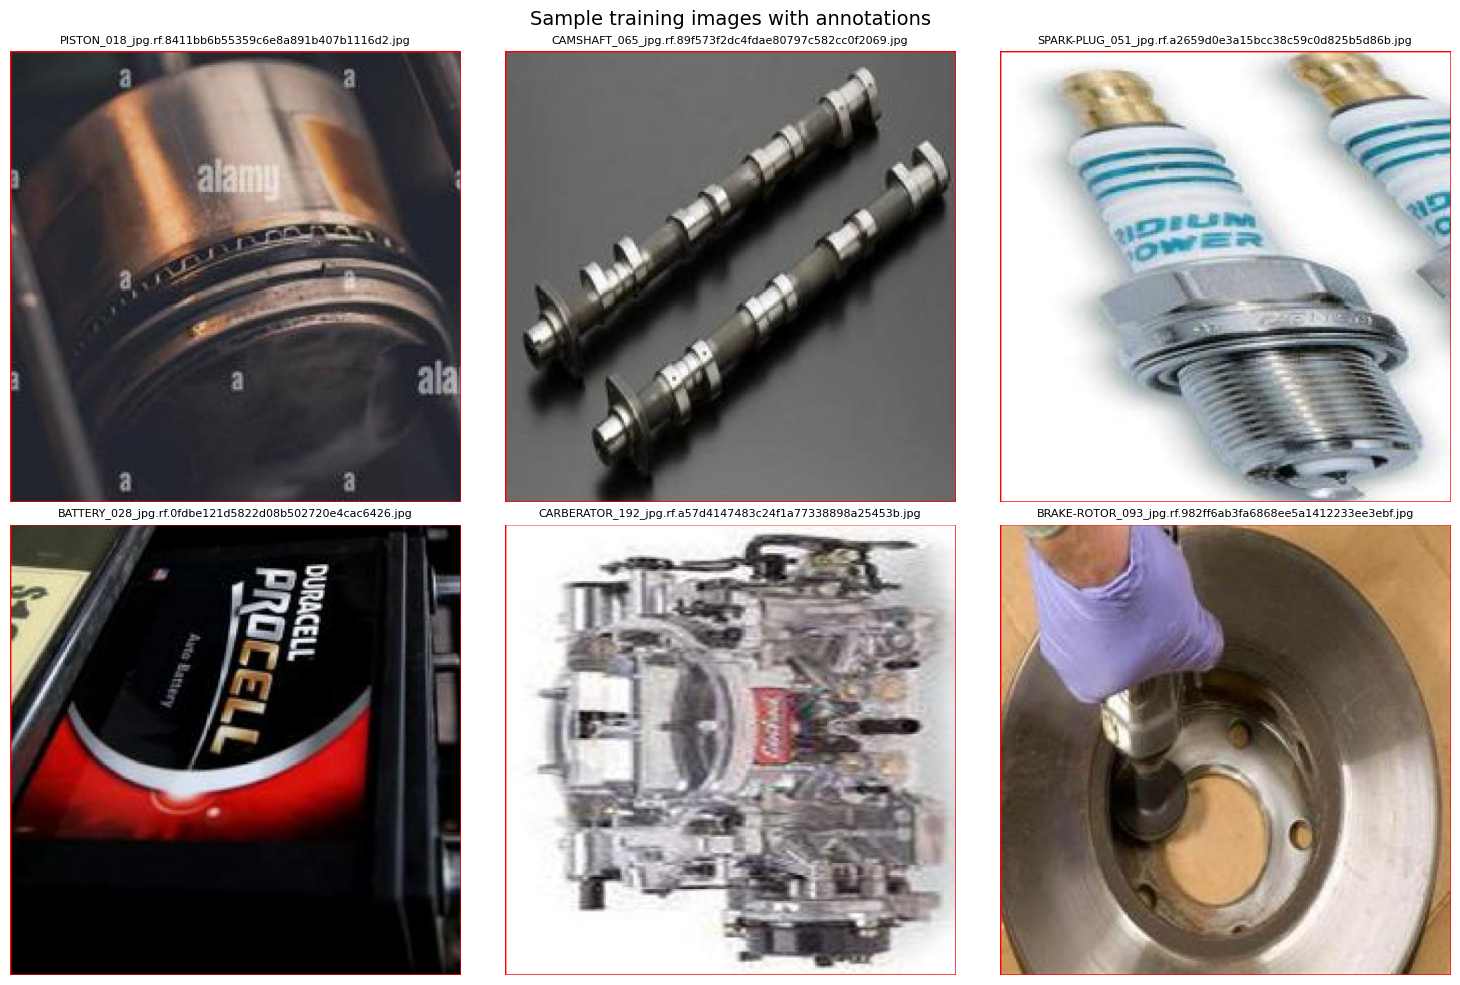

In [8]:
# Visualize sample images with annotations
import cv2
import random

def draw_bboxes(img_path, label_path, class_names):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                cls_id = int(parts[0])
                cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                label = class_names[cls_id] if cls_id < len(class_names) else f'cls_{cls_id}'
                cv2.putText(img, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    return img

# Show 6 random samples
train_images = glob.glob('/content/dataset/train/images/*')
samples = random.sample(train_images, min(6, len(train_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flat, samples):
    label_path = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    img = draw_bboxes(img_path, label_path, class_names)
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path), fontsize=8)
    ax.axis('off')

plt.suptitle('Sample training images with annotations', fontsize=14)
plt.tight_layout()
plt.savefig(f'{DRIVE_PROJECT}/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Experiment 1 — Baseline YOLOv8s
First training run to establish baseline performance.

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv8s
model = YOLO('yolov8s.pt')

# Train baseline
results = model.train(
    data='/content/dataset/data.yaml',
    epochs=100,
    batch=16,
    imgsz=640,
    patience=20,
    device=0,
    optimizer='AdamW',
    lr0=0.001,
    project=f'{DRIVE_PROJECT}/runs',
    name='exp1_yolov8s_baseline',
    save=True,
    save_period=10,
    plots=True,
)

print("\nBaseline training complete!")
print(f"Results saved to: {results.save_dir}")

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp1_yolov8s_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20,

In [ ]:
# Evaluate on test set
model = YOLO(f'{DRIVE_PROJECT}/runs/exp1_yolov8s_baseline/weights/best.pt')
test_results = model.val(
    data='/content/dataset/data.yaml',
    split='test',
    plots=True,
)

print(f"\n{'='*50}")
print(f"BASELINE RESULTS (YOLOv8s)")
print(f"{'='*50}")
print(f"mAP@0.5:      {test_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {test_results.box.map:.4f}")
print(f"Precision:     {test_results.box.mp:.4f}")
print(f"Recall:        {test_results.box.mr:.4f}")

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,144,934 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 28.5±26.4 MB/s, size: 37.3 KB)
val: Scanning /content/dataset/test/labels... 2534 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2534/2534 1.0Kit/s 2.5s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 159/159 4.2it/s 38.0s
                   all       2534       2534      0.924      0.841      0.936      0.935
        AIR COMPRESSOR         48         48      0.887      0.979      0.991      0.991
            ALTERNATOR         52         52      0.956      0.827      0.954      0.952
               BATTERY         50         50      0.938          1      0.993      0.993
         BRAKE CALIPER         60         60       0.84      0.767      0.887     

## 5. Experiment 2 — Architecture comparison (RQ2)
Compare YOLOv8 nano, small, and medium variants.

In [ ]:
import json
import time
from ultralytics import YOLO

architectures = {
    'yolov8n': 'yolov8n.pt',
    'yolov8s': 'yolov8s.pt',
    'yolov8m': 'yolov8m.pt',
}

arch_results = {}

for name, weights in architectures.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")

    model = YOLO(weights)
    start_time = time.time()

    model.train(
        data='/content/dataset/data.yaml',
        epochs=30,
        batch=16,
        imgsz=640,
        patience=20,
        device=0,
        project=f'{DRIVE_PROJECT}/runs',
        name=f'exp2_{name}',
        save=True,
        plots=True,
    )

    training_time = time.time() - start_time

    # Evaluate
    best_model = YOLO(f'{DRIVE_PROJECT}/runs/exp2_{name}/weights/best.pt')
    val = best_model.val(data='/content/dataset/data.yaml', split='test')

    arch_results[name] = {
        'mAP50': round(float(val.box.map50), 4),
        'mAP50_95': round(float(val.box.map), 4),
        'precision': round(float(val.box.mp), 4),
        'recall': round(float(val.box.mr), 4),
        'training_time_min': round(training_time / 60, 1),
    }
    print(f"{name} done in {training_time/60:.1f} min — mAP@0.5: {val.box.map50:.4f}")

# Save results
with open(f'{DRIVE_PROJECT}/exp2_architecture_comparison.json', 'w') as f:
    json.dump(arch_results, f, indent=2)

print("\n\nARCHITECTURE COMPARISON:")
for name, metrics in arch_results.items():
    print(f"  {name}: mAP@0.5={metrics['mAP50']}, Precision={metrics['precision']}, Recall={metrics['recall']}, Time={metrics['training_time_min']}min")


Training: yolov8n
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp2_yolov8n3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

## 6. Experiment 3 — Image resolution impact (RQ2)

In [ ]:
resolutions = [320, 480, 640, 800]
res_results = {}

for imgsz in resolutions:
    print(f"\nTraining with resolution: {imgsz}x{imgsz}")

    model = YOLO('yolov8s.pt')
    start_time = time.time()

    model.train(
        data='/content/dataset/data.yaml',
        epochs=30,
        batch=16 if imgsz <= 640 else 8,  # reduce batch for 800
        imgsz=imgsz,
        patience=10,
        device=0,
        project=f'{DRIVE_PROJECT}/runs',
        name=f'exp3_res{imgsz}',
        save=True,
        plots=True,
    )

    training_time = time.time() - start_time

    best_model = YOLO(f'{DRIVE_PROJECT}/runs/exp3_res{imgsz}/weights/best.pt')
    val = best_model.val(data='/content/dataset/data.yaml', split='test', imgsz=imgsz)

    res_results[str(imgsz)] = {
        'mAP50': round(float(val.box.map50), 4),
        'mAP50_95': round(float(val.box.map), 4),
        'precision': round(float(val.box.mp), 4),
        'recall': round(float(val.box.mr), 4),
        'training_time_min': round(training_time / 60, 1),
    }

with open(f'{DRIVE_PROJECT}/exp3_resolution_comparison.json', 'w') as f:
    json.dump(res_results, f, indent=2)

print("\n\nRESOLUTION COMPARISON:")
for res, metrics in res_results.items():
    print(f"  {res}px: mAP@0.5={metrics['mAP50']}, Time={metrics['training_time_min']}min")

## 7. Experiment 4 — Augmentation strategies (RQ3)

In [ ]:
aug_configs = {
    'no_augmentation': {
        'hsv_h': 0.0, 'hsv_s': 0.0, 'hsv_v': 0.0,
        'degrees': 0.0, 'translate': 0.0, 'scale': 0.0,
        'fliplr': 0.0, 'mosaic': 0.0, 'mixup': 0.0,
    },
    'standard_augmentation': {
        'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4,
        'degrees': 10.0, 'translate': 0.1, 'scale': 0.5,
        'fliplr': 0.5, 'mosaic': 0.0, 'mixup': 0.0,
    },
    'advanced_augmentation': {
        'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4,
        'degrees': 15.0, 'translate': 0.1, 'scale': 0.5,
        'fliplr': 0.5, 'mosaic': 1.0, 'mixup': 0.15,
    },
}

aug_results = {}

for name, aug_params in aug_configs.items():
    print(f"\nTraining: {name}")

    model = YOLO('yolov8s.pt')
    start_time = time.time()

    model.train(
        data='/content/dataset/data.yaml',
        epochs=40,
        batch=16,
        imgsz=640,
        patience=10,
        device=0,
        project=f'{DRIVE_PROJECT}/runs',
        name=f'exp4_{name}',
        save=True,
        plots=True,
        **aug_params,
    )

    training_time = time.time() - start_time

    best_model = YOLO(f'{DRIVE_PROJECT}/runs/exp4_{name}/weights/best.pt')
    val = best_model.val(data='/content/dataset/data.yaml', split='test')

    aug_results[name] = {
        'mAP50': round(float(val.box.map50), 4),
        'mAP50_95': round(float(val.box.map), 4),
        'precision': round(float(val.box.mp), 4),
        'recall': round(float(val.box.mr), 4),
        'training_time_min': round(training_time / 60, 1),
    }

with open(f'{DRIVE_PROJECT}/exp4_augmentation_comparison.json', 'w') as f:
    json.dump(aug_results, f, indent=2)

print("\n\nAUGMENTATION COMPARISON:")
for name, metrics in aug_results.items():
    print(f"  {name}: mAP@0.5={metrics['mAP50']}, Precision={metrics['precision']}, Recall={metrics['recall']}")

## 8. Experiment 5 — Transfer learning vs from scratch (RQ2)

In [ ]:
# Pretrained (transfer learning)
print("Training with pretrained weights (COCO)...")
model_pretrained = YOLO('yolov8s.pt')
start = time.time()
model_pretrained.train(
    data='/content/dataset/data.yaml',
    epochs=50, batch=16, imgsz=640, patience=10, device=0,
    project=f'{DRIVE_PROJECT}/runs', name='exp5_pretrained',
    save=True, plots=True,
)
time_pretrained = time.time() - start

# From scratch
print("\nTraining from scratch...")
model_scratch = YOLO('yolov8s.yaml')  # .yaml = architecture only, no weights
start = time.time()
model_scratch.train(
    data='/content/dataset/data.yaml',
    epochs=100, batch=16, imgsz=640, patience=20, device=0,
    project=f'{DRIVE_PROJECT}/runs', name='exp5_from_scratch',
    save=True, plots=True,
)
time_scratch = time.time() - start

# Evaluate both
tl_results = {}
for name, run_name, t in [('pretrained', 'exp5_pretrained', time_pretrained),
                           ('from_scratch', 'exp5_from_scratch', time_scratch)]:
    best = YOLO(f'{DRIVE_PROJECT}/runs/{run_name}/weights/best.pt')
    val = best.val(data='/content/dataset/data.yaml', split='test')
    tl_results[name] = {
        'mAP50': round(float(val.box.map50), 4),
        'mAP50_95': round(float(val.box.map), 4),
        'precision': round(float(val.box.mp), 4),
        'recall': round(float(val.box.mr), 4),
        'training_time_min': round(t / 60, 1),
    }

with open(f'{DRIVE_PROJECT}/exp5_transfer_learning.json', 'w') as f:
    json.dump(tl_results, f, indent=2)

print("\n\nTRANSFER LEARNING COMPARISON:")
for name, metrics in tl_results.items():
    print(f"  {name}: mAP@0.5={metrics['mAP50']}, Time={metrics['training_time_min']}min")

## 9. Prototype — Detection visualization

In [ ]:
# Load best model and run on test images
best_model = YOLO(f'{DRIVE_PROJECT}/runs/exp1_yolov8s_baseline/weights/best.pt')

# Predict on test images
test_images = glob.glob('/content/dataset/test/images/*')[:10]
results = best_model.predict(
    source=test_images,
    conf=0.25,
    save=True,
    project=f'{DRIVE_PROJECT}/prototype',
    name='detections',
    line_width=2,
)

# Display results
from IPython.display import display

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, r in zip(axes.flat, results):
    img = r.plot()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'{len(r.boxes)} detections', fontsize=9)

plt.suptitle('Prototype: Automotive Component Detection', fontsize=14)
plt.tight_layout()
plt.savefig(f'{DRIVE_PROJECT}/prototype_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPrototype visualizations saved to: {DRIVE_PROJECT}/prototype/")

## 10. Summary — All experiment results

In [ ]:
import pandas as pd



# Load all saved results
summary = {}
for exp_file in glob.glob(f'{DRIVE_PROJECT}/exp*.json'):
    with open(exp_file, 'r') as f:
        data = json.load(f)
        exp_name = os.path.basename(exp_file).replace('.json', '')
        for variant, metrics in data.items():
            summary[f"{exp_name}/{variant}"] = metrics

if summary:
    df = pd.DataFrame(summary).T
    print(df.to_string())
    df.to_csv(f'{DRIVE_PROJECT}/all_results_summary.csv')
    print(f"\nFull summary saved to: {DRIVE_PROJECT}/all_results_summary.csv")
else:
    print("No results found yet. Run the experiments first.")